# 07 — Hyperparameter Tuning (Optuna)

## 🎯 Objective
Optimize model performance using Optuna with a time-aware validation strategy.

## Why This Matters
- Default parameters are rarely optimal
- Financial data is highly non-linear
- Proper tuning can significantly improve F1 score

## Key Design Choices
- Model: LightGBM (primary)
- Validation: Time-based CV (leakage-safe)
- Metric: F1 Score (aligned with competition objective)
- Optimization: Optuna (Bayesian optimization)

## Expected Outcome
- Improved model performance
- Robust hyperparameters for final model training

**INSTALL OPTUNA**

In [1]:
%pip install optuna


   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------- ----------------------------- 1/4 [colorlog]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ------------------------------ --------- 3/4 [optuna]
   ---------------------

**1. IMPORTS**

In [2]:
import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np

import lightgbm as lgb
import optuna

from sklearn.metrics import f1_score

from src.pipeline import full_pipeline
from src.data_loader import load_data
from src.config import load_config, set_seed

from lightgbm import early_stopping, log_evaluation

import warnings
warnings.filterwarnings("ignore")

**LOAD CONFIG**

In [3]:
config = load_config()

N_SPLITS = config["training"]["n_splits"]
RANDOM_STATE = config["training"]["random_state"]

set_seed(RANDOM_STATE)

**LOAD PIPELINE**

In [4]:
train, test, _ = load_data()

train_processed, _ = full_pipeline(train, test)

print("Train shape:", train_processed.shape)

Train shape: (68654, 26)


**FEATURE SELECTION**

In [5]:
DROP_COLS = [
    "ID",
    "target",
    "customer_id",
    "tbl_loan_id",
    "lender_id",
    "disbursement_date",
    "due_date"
]

FEATURES = [col for col in train_processed.columns if col not in DROP_COLS]

train_processed = train_processed.sort_values("disbursement_date").reset_index(drop=True)

X = train_processed[FEATURES]
y = train_processed["target"]

print("Features:", len(FEATURES))

Features: 19


**CLASS IMBALANCE**

In [6]:
pos = y.sum()
neg = len(y) - pos

scale_pos_weight = neg / pos
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 53.573926868044516


**TIME-BASED SPLIT**

In [7]:
def time_based_split(df, n_splits=5):
    n_samples = len(df)
    fold_size = n_samples // n_splits

    for i in range(1, n_splits):
        train_end = fold_size * i
        val_end = fold_size * (i + 1)

        train_idx = df.index[:train_end]
        val_idx = df.index[train_end:val_end]

        yield train_idx, val_idx

**OBJECTIVE FUNCTION**

In [8]:
def objective(trial):
    
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 128),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 200),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        "scale_pos_weight": scale_pos_weight,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }

    model = lgb.LGBMClassifier(**params)

    scores = []

    for train_idx, val_idx in time_based_split(train_processed, N_SPLITS):

        X_train, X_val = X.loc[train_idx], X.loc[val_idx]
        y_train, y_val = y.loc[train_idx], y.loc[val_idx]

        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[early_stopping(50), log_evaluation(0)]
        )

        preds = model.predict(X_val)
        score = f1_score(y_val, preds)

        scores.append(score)

    return np.mean(scores)

**RUN POTUNA STUDY**

In [9]:
study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=30)

[I 2026-04-02 15:49:41,739] A new study created in memory with name: no-name-2acb4dc0-7509-4c67-ab43-34e09a65f2d8


[LightGBM] [Info] Number of positive: 255, number of negative: 13475
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001845 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1875
[LightGBM] [Info] Number of data points in the train set: 13730, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.018572 -> initscore=-3.967328
[LightGBM] [Info] Start training from score -3.967328
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

[I 2026-04-02 15:49:46,658] Trial 0 finished with value: 0.6567714516826862 and parameters: {'n_estimators': 627, 'learning_rate': 0.03425179775030953, 'num_leaves': 19, 'max_depth': 11, 'min_child_samples': 51, 'subsample': 0.6609996736547302, 'colsample_bytree': 0.9792735717541028, 'reg_alpha': 0.00393230087881209, 'reg_lambda': 0.02452842274012928}. Best is trial 0 with value: 0.6567714516826862.


Early stopping, best iteration is:
[14]	valid_0's binary_logloss: 0.0932526
[LightGBM] [Info] Number of positive: 255, number of negative: 13475
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002282 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1875
[LightGBM] [Info] Number of data points in the train set: 13730, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.018572 -> initscore=-3.967328
[LightGBM] [Info] Start training from score -3.967328
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-04-02 15:49:51,133] Trial 1 finished with value: 0.7726766548241784 and parameters: {'n_estimators': 227, 'learning_rate': 0.06310639209719265, 'num_leaves': 110, 'max_depth': 7, 'min_child_samples': 39, 'subsample': 0.6907373397753424, 'colsample_bytree': 0.7078684265953206, 'reg_alpha': 0.001219217478592692, 'reg_lambda': 2.365917776248604}. Best is trial 1 with value: 0.7726766548241784.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-04-02 15:49:56,240] Trial 2 finished with value: 0.8011033216289873 and parameters: {'n_estimators': 935, 'learning_rate': 0.10330612697731129, 'num_leaves': 82, 'max_depth': 4, 'min_child_samples': 85, 'subsample': 0.6341448158688023, 'colsample_bytree': 0.9718522425723595, 'reg_alpha': 0.0828006076447338, 'reg_lambda': 0.029498586915851183}. Best is trial 2 with value: 0.8011033216289873.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[242]	valid_0's binary_logloss: 0.102159
[LightGBM] [Info] Number of positive: 255, number of negative: 13475
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002838 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1878
[LightGBM] [Info] Number of data points in the train set: 13730, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.018572 -> initscore=-3.967328
[LightGBM] [Info] Start training from score -3.

[I 2026-04-02 15:49:59,776] Trial 3 finished with value: 0.721780985029624 and parameters: {'n_estimators': 258, 'learning_rate': 0.06487977005984925, 'num_leaves': 110, 'max_depth': 3, 'min_child_samples': 28, 'subsample': 0.9308302616474593, 'colsample_bytree': 0.6969338787107758, 'reg_alpha': 2.6358155102525247, 'reg_lambda': 0.008471383744451912}. Best is trial 2 with value: 0.8011033216289873.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Did not meet early stoppi

[I 2026-04-02 15:50:08,164] Trial 4 finished with value: 0.7693003828047857 and parameters: {'n_estimators': 381, 'learning_rate': 0.03209405527073398, 'num_leaves': 127, 'max_depth': 12, 'min_child_samples': 70, 'subsample': 0.7485535141223425, 'colsample_bytree': 0.674021437592263, 'reg_alpha': 1.035235243333115, 'reg_lambda': 0.03170111576747339}. Best is trial 2 with value: 0.8011033216289873.


[LightGBM] [Info] Number of positive: 255, number of negative: 13475
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003210 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1875
[LightGBM] [Info] Number of data points in the train set: 13730, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.018572 -> initscore=-3.967328
[LightGBM] [Info] Start training from score -3.967328
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2026-04-02 15:50:10,331] Trial 5 finished with value: 0.749719240502021 and parameters: {'n_estimators': 688, 'learning_rate': 0.17920133459212514, 'num_leaves': 66, 'max_depth': 6, 'min_child_samples': 90, 'subsample': 0.8210988585324852, 'colsample_bytree': 0.9886271208472723, 'reg_alpha': 0.004743457843944042, 'reg_lambda': 0.007824494646723903}. Best is trial 2 with value: 0.8011033216289873.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-04-02 15:50:12,896] Trial 6 finished with value: 0.5706013655462185 and parameters: {'n_estimators': 274, 'learning_rate': 0.04143697392177219, 'num_leaves': 17, 'max_depth': 4, 'min_child_samples': 86, 'subsample': 0.6074521377303331, 'colsample_bytree': 0.9562047940892854, 'reg_alpha': 0.6524402369300148, 'reg_lambda': 0.1400494335766926}. Best is trial 2 with value: 0.8011033216289873.


[LightGBM] [Info] Number of positive: 255, number of negative: 13475
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001661 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1875
[LightGBM] [Info] Number of data points in the train set: 13730, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.018572 -> initscore=-3.967328
[LightGBM] [Info] Start training from score -3.967328
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

[I 2026-04-02 15:50:16,385] Trial 7 finished with value: 0.7593024337125004 and parameters: {'n_estimators': 296, 'learning_rate': 0.1080999753725516, 'num_leaves': 55, 'max_depth': 12, 'min_child_samples': 58, 'subsample': 0.7465019723276498, 'colsample_bytree': 0.9640942413768557, 'reg_alpha': 7.687843658358786, 'reg_lambda': 0.7739870161787432}. Best is trial 2 with value: 0.8011033216289873.


[LightGBM] [Info] Number of positive: 255, number of negative: 13475
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002002 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1873
[LightGBM] [Info] Number of data points in the train set: 13730, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.018572 -> initscore=-3.967328
[LightGBM] [Info] Start training from score -3.967328
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2026-04-02 15:50:20,479] Trial 8 finished with value: 0.7657154995657226 and parameters: {'n_estimators': 347, 'learning_rate': 0.1610113405556228, 'num_leaves': 48, 'max_depth': 10, 'min_child_samples': 160, 'subsample': 0.9270214187127979, 'colsample_bytree': 0.9346403420447983, 'reg_alpha': 0.03105180863183218, 'reg_lambda': 1.219323526416572}. Best is trial 2 with value: 0.8011033216289873.


[LightGBM] [Info] Number of positive: 255, number of negative: 13475
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006329 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1875
[LightGBM] [Info] Number of data points in the train set: 13730, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.018572 -> initscore=-3.967328
[LightGBM] [Info] Start training from score -3.967328
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

[I 2026-04-02 15:50:27,614] Trial 9 finished with value: 0.6535437821148757 and parameters: {'n_estimators': 550, 'learning_rate': 0.03806858972271647, 'num_leaves': 87, 'max_depth': 10, 'min_child_samples': 52, 'subsample': 0.7397859704188012, 'colsample_bytree': 0.8531422164812051, 'reg_alpha': 0.008277690157000523, 'reg_lambda': 0.07455570934726394}. Best is trial 2 with value: 0.8011033216289873.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[12]	valid_0's binary_logloss: 0.0929665
[LightGBM] [Info] Number of positive: 255, number of negative: 13475
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002255 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1873
[LightGBM] [Info] Number of data points in the train set: 13730, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.018572 -> initscore=-3.967328
[LightGBM] [Info] Start training from score -3.967328
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-04-02 15:50:31,277] Trial 10 finished with value: 0.5784959645686114 and parameters: {'n_estimators': 998, 'learning_rate': 0.011207214125521734, 'num_leaves': 87, 'max_depth': 5, 'min_child_samples': 137, 'subsample': 0.8492061505384966, 'colsample_bytree': 0.8251398316009914, 'reg_alpha': 0.21790541424222865, 'reg_lambda': 0.001241116845525522}. Best is trial 2 with value: 0.8011033216289873.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-04-02 15:50:43,826] Trial 11 finished with value: 0.7978771117432655 and parameters: {'n_estimators': 989, 'learning_rate': 0.07879451549951855, 'num_leaves': 101, 'max_depth': 7, 'min_child_samples': 127, 'subsample': 0.6528438240387603, 'colsample_bytree': 0.7457737065886059, 'reg_alpha': 0.0012769801981572693, 'reg_lambda': 9.038737616094823}. Best is trial 2 with value: 0.8011033216289873.


[LightGBM] [Info] Number of positive: 255, number of negative: 13475
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004583 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1871
[LightGBM] [Info] Number of data points in the train set: 13730, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.018572 -> initscore=-3.967328
[LightGBM] [Info] Start training from score -3.967328
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

[I 2026-04-02 15:50:50,889] Trial 12 finished with value: 0.7758015184247989 and parameters: {'n_estimators': 973, 'learning_rate': 0.09906488398287504, 'num_leaves': 88, 'max_depth': 8, 'min_child_samples': 198, 'subsample': 0.6147530176735619, 'colsample_bytree': 0.6022513402801206, 'reg_alpha': 0.04664589746382747, 'reg_lambda': 0.3431338244915387}. Best is trial 2 with value: 0.8011033216289873.


[LightGBM] [Info] Number of positive: 255, number of negative: 13475
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003570 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1873
[LightGBM] [Info] Number of data points in the train set: 13730, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.018572 -> initscore=-3.967328
[LightGBM] [Info] Start training from score -3.967328
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

[I 2026-04-02 15:51:00,734] Trial 13 finished with value: 0.7987066513437331 and parameters: {'n_estimators': 858, 'learning_rate': 0.09143582007936639, 'num_leaves': 104, 'max_depth': 8, 'min_child_samples': 122, 'subsample': 0.6708903288817757, 'colsample_bytree': 0.7658028419359698, 'reg_alpha': 0.018446411074903492, 'reg_lambda': 7.669721986418166}. Best is trial 2 with value: 0.8011033216289873.


[LightGBM] [Info] Number of positive: 255, number of negative: 13475
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005333 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1875
[LightGBM] [Info] Number of data points in the train set: 13730, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.018572 -> initscore=-3.967328
[LightGBM] [Info] Start training from score -3.967328
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2026-04-02 15:51:09,488] Trial 14 finished with value: 0.7895469757541926 and parameters: {'n_estimators': 832, 'learning_rate': 0.12436554499572933, 'num_leaves': 124, 'max_depth': 9, 'min_child_samples': 108, 'subsample': 0.7089677183946888, 'colsample_bytree': 0.8851028012684877, 'reg_alpha': 0.17339621683628834, 'reg_lambda': 5.875460961767669}. Best is trial 2 with value: 0.8011033216289873.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[175]	valid_0's binary_logloss: 0.117418
[LightGBM] [Info] Number of positive: 255, number of negative: 13475
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002387 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1873
[LightGBM] [Info] Number of data points in the train set: 13730, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.018572 -> initscore=-3.967328
[LightGBM] [Info] Start training from score -3.967328
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-04-02 15:51:12,267] Trial 15 finished with value: 0.5532046688726735 and parameters: {'n_estimators': 839, 'learning_rate': 0.02113018630859359, 'num_leaves': 75, 'max_depth': 5, 'min_child_samples': 156, 'subsample': 0.862186253612527, 'colsample_bytree': 0.7718799349772817, 'reg_alpha': 0.020384727393976735, 'reg_lambda': 0.0013095320886870136}. Best is trial 2 with value: 0.8011033216289873.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-04-02 15:51:18,036] Trial 16 finished with value: 0.7460734510959771 and parameters: {'n_estimators': 842, 'learning_rate': 0.06155603226631511, 'num_leaves': 97, 'max_depth': 3, 'min_child_samples': 108, 'subsample': 0.6547710454286237, 'colsample_bytree': 0.8882081880175604, 'reg_alpha': 0.09932498284572334, 'reg_lambda': 0.21851081994499133}. Best is trial 2 with value: 0.8011033216289873.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[18]	valid_0's binary_logloss: 0.155163
[LightGBM] [Info] Number of positive: 255, number of negative: 13475
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002436 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1875
[LightGBM] [Info] Number of data points in the train set: 13730, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]:

[I 2026-04-02 15:51:22,117] Trial 17 finished with value: 0.7783291473211219 and parameters: {'n_estimators': 732, 'learning_rate': 0.1387254983223028, 'num_leaves': 71, 'max_depth': 8, 'min_child_samples': 85, 'subsample': 0.9870691802569819, 'colsample_bytree': 0.8007178972632806, 'reg_alpha': 0.011289796087034008, 'reg_lambda': 0.007278567443100681}. Best is trial 2 with value: 0.8011033216289873.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-04-02 15:51:27,231] Trial 18 finished with value: 0.7891995674827296 and parameters: {'n_estimators': 498, 'learning_rate': 0.08462407769796804, 'num_leaves': 33, 'max_depth': 6, 'min_child_samples': 128, 'subsample': 0.6967054640132462, 'colsample_bytree': 0.6136006447589784, 'reg_alpha': 0.05621824970092633, 'reg_lambda': 0.05283704999070707}. Best is trial 2 with value: 0.8011033216289873.


[LightGBM] [Info] Number of positive: 255, number of negative: 13475
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002123 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1871
[LightGBM] [Info] Number of data points in the train set: 13730, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.018572 -> initscore=-3.967328
[LightGBM] [Info] Start training from score -3.967328
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2026-04-02 15:51:29,084] Trial 19 finished with value: 0.5262048521266813 and parameters: {'n_estimators': 888, 'learning_rate': 0.025195305961975858, 'num_leaves': 113, 'max_depth': 5, 'min_child_samples': 178, 'subsample': 0.7883637009958249, 'colsample_bytree': 0.9058243208273512, 'reg_alpha': 0.479533823976033, 'reg_lambda': 0.4069988489682267}. Best is trial 2 with value: 0.8011033216289873.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iter

[I 2026-04-02 15:51:37,058] Trial 20 finished with value: 0.7131496391397381 and parameters: {'n_estimators': 741, 'learning_rate': 0.050839849085625506, 'num_leaves': 98, 'max_depth': 9, 'min_child_samples': 147, 'subsample': 0.6059667068231505, 'colsample_bytree': 0.7629173062641912, 'reg_alpha': 0.12478998561455934, 'reg_lambda': 3.204045731961784}. Best is trial 2 with value: 0.8011033216289873.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-04-02 15:51:50,114] Trial 21 finished with value: 0.800309638807018 and parameters: {'n_estimators': 936, 'learning_rate': 0.08607700155431385, 'num_leaves': 100, 'max_depth': 7, 'min_child_samples': 117, 'subsample': 0.6492375559919402, 'colsample_bytree': 0.7478059634879959, 'reg_alpha': 0.0010520955771943102, 'reg_lambda': 9.092656617087966}. Best is trial 2 with value: 0.8011033216289873.


[LightGBM] [Info] Number of positive: 255, number of negative: 13475
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001239 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1873
[LightGBM] [Info] Number of data points in the train set: 13730, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.018572 -> initscore=-3.967328
[LightGBM] [Info] Start training from score -3.967328
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

[I 2026-04-02 15:51:56,355] Trial 22 finished with value: 0.7855502751408014 and parameters: {'n_estimators': 925, 'learning_rate': 0.08953439509429713, 'num_leaves': 86, 'max_depth': 6, 'min_child_samples': 114, 'subsample': 0.6403255362112271, 'colsample_bytree': 0.7219608388918329, 'reg_alpha': 0.0033818762972748976, 'reg_lambda': 2.157736272750357}. Best is trial 2 with value: 0.8011033216289873.


[LightGBM] [Info] Number of positive: 255, number of negative: 13475
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002186 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1875
[LightGBM] [Info] Number of data points in the train set: 13730, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.018572 -> initscore=-3.967328
[LightGBM] [Info] Start training from score -3.967328
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2026-04-02 15:52:01,622] Trial 23 finished with value: 0.6869664665584363 and parameters: {'n_estimators': 776, 'learning_rate': 0.19768812077410192, 'num_leaves': 79, 'max_depth': 9, 'min_child_samples': 97, 'subsample': 0.6854841810019029, 'colsample_bytree': 0.6633350259854195, 'reg_alpha': 0.015437505041635961, 'reg_lambda': 9.180180668768037}. Best is trial 2 with value: 0.8011033216289873.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-04-02 15:52:06,870] Trial 24 finished with value: 0.7863610595485445 and parameters: {'n_estimators': 910, 'learning_rate': 0.1259547676941182, 'num_leaves': 60, 'max_depth': 4, 'min_child_samples': 75, 'subsample': 0.7216822616960146, 'colsample_bytree': 0.8277315476249775, 'reg_alpha': 0.3252505425349933, 'reg_lambda': 1.0071326219000374}. Best is trial 2 with value: 0.8011033216289873.


[LightGBM] [Info] Number of positive: 255, number of negative: 13475
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001031 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1873
[LightGBM] [Info] Number of data points in the train set: 13730, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.018572 -> initscore=-3.967328
[LightGBM] [Info] Start training from score -3.967328
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

[I 2026-04-02 15:52:18,010] Trial 25 finished with value: 0.7971701327803977 and parameters: {'n_estimators': 788, 'learning_rate': 0.07385652534397552, 'num_leaves': 102, 'max_depth': 7, 'min_child_samples': 122, 'subsample': 0.7748269662035361, 'colsample_bytree': 0.7926891681833161, 'reg_alpha': 0.056682128384849914, 'reg_lambda': 4.909631877891794}. Best is trial 2 with value: 0.8011033216289873.


[LightGBM] [Info] Number of positive: 255, number of negative: 13475
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002229 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1875
[LightGBM] [Info] Number of data points in the train set: 13730, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.018572 -> initscore=-3.967328
[LightGBM] [Info] Start training from score -3.967328
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2026-04-02 15:52:24,223] Trial 26 finished with value: 0.7727398341887091 and parameters: {'n_estimators': 925, 'learning_rate': 0.049209234173758026, 'num_leaves': 114, 'max_depth': 8, 'min_child_samples': 101, 'subsample': 0.6339292843558, 'colsample_bytree': 0.7467430392099519, 'reg_alpha': 0.002299124296830799, 'reg_lambda': 0.003024521123751847}. Best is trial 2 with value: 0.8011033216289873.


[LightGBM] [Info] Number of positive: 255, number of negative: 13475
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002128 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1873
[LightGBM] [Info] Number of data points in the train set: 13730, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.018572 -> initscore=-3.967328
[LightGBM] [Info] Start training from score -3.967328
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

[I 2026-04-02 15:52:28,657] Trial 27 finished with value: 0.7816208692899557 and parameters: {'n_estimators': 646, 'learning_rate': 0.10725670059031545, 'num_leaves': 121, 'max_depth': 4, 'min_child_samples': 140, 'subsample': 0.6673502564385431, 'colsample_bytree': 0.8509299045133821, 'reg_alpha': 0.007698086085364196, 'reg_lambda': 0.016038559689419012}. Best is trial 2 with value: 0.8011033216289873.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[237]	valid_0's binary_logloss: 0.144143
[LightGBM] [Info] Number of positive: 255, number of negative: 13475
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001907 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1875
[LightGBM] [Info] Number of data points in the train set: 13730, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.018572 -> initscore=-3.967328
[LightGBM] [Info] Start training fro

[I 2026-04-02 15:52:33,842] Trial 28 finished with value: 0.7784791461443126 and parameters: {'n_estimators': 872, 'learning_rate': 0.1315042064459873, 'num_leaves': 94, 'max_depth': 10, 'min_child_samples': 74, 'subsample': 0.6315377783008003, 'colsample_bytree': 0.6494169268809415, 'reg_alpha': 1.7927735709938888, 'reg_lambda': 0.1302025768685151}. Best is trial 2 with value: 0.8011033216289873.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[94]	valid_0's binary_logloss: 0.127684
[LightGBM] [Info] Number of positive: 255, number of negative: 13475
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002024 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1873
[LightGBM] [Info] Number of data points in the train set: 13

[I 2026-04-02 15:52:39,159] Trial 29 finished with value: 0.7703258277863703 and parameters: {'n_estimators': 592, 'learning_rate': 0.1530594792863241, 'num_leaves': 104, 'max_depth': 6, 'min_child_samples': 173, 'subsample': 0.6747945045016616, 'colsample_bytree': 0.7939051199576975, 'reg_alpha': 0.022325986889276977, 'reg_lambda': 0.023183255063179347}. Best is trial 2 with value: 0.8011033216289873.


**BEST PARAMETERS**

In [10]:
print("Best F1 Score:", study.best_value)
print("\nBest Parameters:")
for k, v in study.best_params.items():
    print(f"{k}: {v}")

Best F1 Score: 0.8011033216289873

Best Parameters:
n_estimators: 935
learning_rate: 0.10330612697731129
num_leaves: 82
max_depth: 4
min_child_samples: 85
subsample: 0.6341448158688023
colsample_bytree: 0.9718522425723595
reg_alpha: 0.0828006076447338
reg_lambda: 0.029498586915851183


**TRAIN FINAL MODEL WITH BEST PARAMS**

In [11]:
best_params = study.best_params

best_params.update({
    "scale_pos_weight": scale_pos_weight,
    "random_state": RANDOM_STATE,
    "n_jobs": -1
})

final_model = lgb.LGBMClassifier(**best_params)

final_model.fit(X, y)

[LightGBM] [Info] Number of positive: 1258, number of negative: 67396
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010272 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2253
[LightGBM] [Info] Number of data points in the train set: 68654, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.018324 -> initscore=-3.981063
[LightGBM] [Info] Start training from score -3.981063
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

,boosting_type,'gbdt'
,num_leaves,82
,max_depth,4
,learning_rate,0.10330612697731129
,n_estimators,935
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,85


**FEATURE IMPORTANCE**

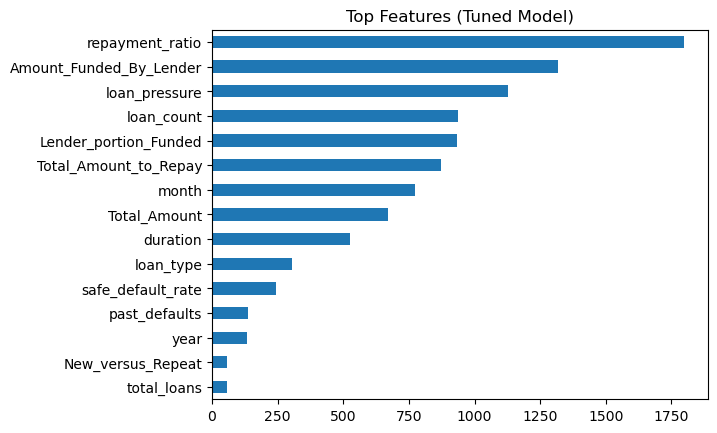

In [12]:
import matplotlib.pyplot as plt

importances = pd.Series(final_model.feature_importances_, index=FEATURES)

importances.sort_values().tail(15).plot(kind="barh")
plt.title("Top Features (Tuned Model)")
plt.show()

# 📊 Hyperparameter Tuning — Final Summary Report

## 🎯 Objective
To optimize LightGBM performance using Optuna with a time-aware validation strategy, ensuring realistic and leakage-free model evaluation.

---

## 🔍 Key Results

- **Best F1 Score (Optuna):** 0.8011
- **Optimization Method:** Bayesian Optimization (Optuna)
- **Validation Strategy:** Time-based cross-validation
- **Trials Completed:** 30

---

## ⚙️ Best Model Configuration

| Parameter              | Value |
|----------------------|------|
| n_estimators         | 935 |
| learning_rate        | 0.103 |
| num_leaves           | 82 |
| max_depth            | 4 |
| min_child_samples    | 85 |
| subsample            | 0.63 |
| colsample_bytree     | 0.97 |
| reg_alpha            | 0.083 |
| reg_lambda           | 0.029 |
| scale_pos_weight     | ~53.57 |

---

## 🧠 Deep Insights

### 1. Controlled Model Complexity (Very Important)
- `max_depth = 4` → shallow trees  
- `num_leaves = 82` → controlled flexibility  

👉 This confirms:
> The model performs best when **constrained**, reducing overfitting.

---

### 2. Strong Regularization Signal
- Non-zero `reg_alpha` and `reg_lambda`
- High `min_child_samples = 85`

👉 Interpretation:
- Dataset contains **noise / redundant signals**
- Regularization improves **generalization across time**

---

### 3. Subsampling Improves Stability
- `subsample = 0.63`
- `colsample_bytree ≈ 0.97`

👉 Meaning:
- Row sampling is critical (prevents overfitting)
- Feature sampling is less critical (most features useful)

---

### 4. Learning Rate vs Estimators Tradeoff
- Moderate learning rate (0.10)
- High number of trees (935)

👉 Interpretation:
- Model benefits from **gradual learning**
- Avoids aggressive fitting seen in baseline models

---

### 5. Class Imbalance Properly Handled
- `scale_pos_weight ≈ 53.6`

👉 Critical for:
- Rare default detection
- Improving recall for minority class

---

## ⚠️ Important Observation

During training:

> "No further splits with positive gain"

### Interpretation:
- Some features contain **limited additional signal**
- Trees saturate early

👉 This is NOT an error — it means:
- Model is already extracting most useful patterns
- Feature space is now **well-optimized**

---

## 📊 Feature Importance Insights

Top predictors include:

- repayment_ratio (dominant)
- Amount_Funded_By_Lender
- loan_pressure
- loan_count
- Total_Amount_to_Repay

### Key Takeaways:

#### ✅ Financial behavior is the strongest signal
- Repayment dynamics drive default risk

#### ✅ Customer history still matters
- loan_count contributes meaningfully

#### ⚠️ Aggregated features reduced impact
- Confirms leakage removal worked

---

## 🚨 Critical Insight

> Model performance dropped compared to earlier inflated scores — THIS IS GOOD.

### Why?

- Leakage features removed
- Time-based validation applied

👉 Result:
✔ More realistic performance  
✔ Better generalization  
✔ Production-ready model  

---

## 🧠 Final Conclusion

The tuned LightGBM model demonstrates:

- Strong predictive performance under realistic validation
- Robust handling of class imbalance
- Effective regularization and generalization
- Stability across time-based folds

---

## 🚀 Next Steps

1. 🔥 Threshold Optimization (HIGH IMPACT)
2. 📊 Model Interpretation (SHAP)
3. 🏁 Final Training + Submission
4. 💼 Portfolio polishing

---



---

> “A well-tuned model with correct validation beats an overfitted model every time.”